In [21]:
import os
import random
import time
import copy # To copy models if needed

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, Subset, random_split
from timm import create_model # For Xception

from sklearn.model_selection import train_test_split # Used indirectly via random_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score
from sklearn.manifold import TSNE
from PIL import Image
from lime import lime_image
from lime.wrappers.scikit_image import SegmentationAlgorithm

import matplotlib.pyplot as plt
from tqdm.notebook import tqdm # Use tqdm.notebook for Jupyter, plain tqdm otherwise
import numpy as np
import pandas as pd
import seaborn as sns

# --- Configuration ---
# !!! ADJUST PATHS AND PARAMETERS AS NEEDED !!!
DATASET_PATH = r"C:\Users\THILAK R\OneDrive\Desktop\chest_cancer"# Path to ImageFolder dataset
MODEL_SAVE_DIR = r"C:\Users\THILAK R\OneDrive\Desktop\Reccurence Lung Cancer\Models" # Directory to save best models
RESULTS_SAVE_PATH = r"C:\Users\THILAK R\OneDrive\Desktop\Reccurence Lung Cancer\Results"
ENSEMBLE_RESULTS_SAVE_PATH = r"C:\Users\THILAK R\OneDrive\Desktop\Reccurence Lung Cancer\Ensemble_Results"
PLOTS_SAVE_DIR = r"C:\Users\THILAK R\OneDrive\Desktop\Reccurence Lung Cancer\Plot_save" # Directory to save plots


# Training Params
BATCH_SIZE = 32
NUM_EPOCHS = 10 # Max epochs per model (adjust as needed)
LEARNING_RATE = 0.001
PATIENCE_EARLY_STOP = 3 # Epochs to wait for improvement before stopping
SPLIT_RATIO = (0.7, 0.15, 0.15) # Train, Validation, Test ratio for slices
EARLY_STOP_THRESHOLD = 0.98 # Added from previous version

# Ensemble Weights (Ensure they sum to 1 or normalize later)
ENSEMBLE_WEIGHTS = {
    "ResNet18": 0.20, "EfficientNet": 0.25, "DenseNet121": 0.25,
    "Xception": 0.15, "MobileNetV2": 0.15,
}
total_weight = sum(ENSEMBLE_WEIGHTS.values())
ENSEMBLE_WEIGHTS = {name: weight / total_weight for name, weight in ENSEMBLE_WEIGHTS.items()}
print(f"Normalized Ensemble Weights: {ENSEMBLE_WEIGHTS}")


# *** ADD THESE LINES ***
# CT Windowing (Lung Window example) - Adjust if needed
WINDOW_CENTER = -600
WINDOW_WIDTH = 1500
# **********************

# --- Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
os.makedirs(PLOTS_SAVE_DIR, exist_ok=True)
print("*"*30 + "\nUsing custom DICOM dataset loader.\n" + "*"*30) # Updated warning slightly

Normalized Ensemble Weights: {'ResNet18': 0.2, 'EfficientNet': 0.25, 'DenseNet121': 0.25, 'Xception': 0.15, 'MobileNetV2': 0.15}
Using device: cuda
******************************
Using custom DICOM dataset loader.
******************************


In [23]:
# Add these imports at the beginning
import pydicom
from torch.utils.data import Dataset # Make sure Dataset is imported
import os
import numpy as np
from PIL import Image
import torch # Added torch import if needed within class

# --- Helper function for DICOM preprocessing ---
def apply_window(img_array, center, width):
    """Applies Hounsfield unit windowing and normalizes 0-1."""
    min_val = center - width // 2
    max_val = center + width // 2
    img_array = np.clip(img_array, min_val, max_val)
    # Normalize to 0-1 within the window
    if max_val > min_val:
        img_array = (img_array - min_val) / (max_val - min_val)
    else: # Handle case where window width is zero or min/max are same
        img_array = np.zeros_like(img_array)
    return img_array

# --- Custom Dataset Class for DICOM ---
class DicomImageFolderDataset(Dataset):
    # *** ADD 'self' AS THE FIRST ARGUMENT HERE ***
    def __init__(self, root_dir, window_center=None, window_width=None, transform=None): # Keep transform optional here
        self.root_dir = root_dir
        self.window_center = window_center
        self.window_width = window_width
        self.transform = transform # Store transform if passed, but usually applied later

        self.classes = sorted([d.name for d in os.scandir(root_dir) if d.is_dir()])
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        self.samples = self._find_samples()
        self.targets = [s[1] for s in self.samples] # Store targets for stratification

        if not self.samples:
            raise FileNotFoundError(f"Found no '.dcm' files in subfolders of {root_dir}")

    def _find_samples(self):
        samples = []
        for class_name in self.classes:
            class_idx = self.class_to_idx[class_name]
            class_dir = os.path.join(self.root_dir, class_name)
            if not os.path.isdir(class_dir):
                continue
            for fname in sorted(os.listdir(class_dir)):
                if fname.lower().endswith('.dcm'):
                    path = os.path.join(class_dir, fname)
                    item = (path, class_idx)
                    samples.append(item)
        return samples

    def __len__(self):
        return len(self.samples)

    # *** THE REST OF THE CLASS (__getitem__) REMAINS THE SAME ***
    def __getitem__(self, idx):
        filepath, label = self.samples[idx]
        # print(f"DEBUG: Attempting to load index {idx}, path: {filepath}") # <-- Add for detailed debug
        try:
            # Load DICOM
            ds = pydicom.dcmread(filepath, stop_before_pixels=False) # Ensure pixels are read

            # Basic check if pixel data exists
            if not hasattr(ds, 'PixelData') or ds.PixelData is None:
                 raise ValueError(f"No PixelData found in DICOM file: {filepath}")

            img_array = ds.pixel_array.astype(np.float32)
            # print(f"DEBUG: Loaded {filepath}, Original shape: {img_array.shape}, dtype: {img_array.dtype}") # <-- Add

            # Apply slope/intercept if available
            slope = float(ds.RescaleSlope) if 'RescaleSlope' in ds else 1.0
            intercept = float(ds.RescaleIntercept) if 'RescaleIntercept' in ds else 0.0
            if slope != 1.0 or intercept != 0.0:
                img_array = img_array * slope + intercept
                # print(f"DEBUG: Applied slope/intercept. Range: {img_array.min():.1f} - {img_array.max():.1f}") # <-- Add

            # Apply windowing
            if self.window_center is not None and self.window_width is not None:
                img_array_windowed = apply_window(img_array, self.window_center, self.window_width)
                # print(f"DEBUG: Applied windowing. Range: {img_array_windowed.min():.2f} - {img_array_windowed.max():.2f}") # <-- Add
            else:
                # Fallback: Basic min-max normalization if no windowing specified
                min_val, max_val = np.min(img_array), np.max(img_array)
                if max_val > min_val:
                    img_array_windowed = (img_array - min_val) / (max_val - min_val)
                else:
                    img_array_windowed = np.zeros_like(img_array)
                # print(f"DEBUG: Applied MinMax scaling. Range: {img_array_windowed.min():.2f} - {img_array_windowed.max():.2f}") # <-- Add

            # Check for NaNs/Infs *after* processing
            if np.isnan(img_array_windowed).any() or np.isinf(img_array_windowed).any():
                 raise ValueError(f"NaN or Inf detected in processed pixel array for {filepath}")

            # Convert normalized float (0-1) array to uint8 PIL Image (0-255)
            # Clamp values just in case before scaling
            img_array_clamped = np.clip(img_array_windowed, 0.0, 1.0)
            img_array_uint8 = (img_array_clamped * 255).astype(np.uint8)
            img_pil = Image.fromarray(img_array_uint8)
            # print(f"DEBUG: Converted to PIL Image.") # <-- Add

            # Convert grayscale PIL to 3 channels for standard models
            img_pil_rgb = img_pil.convert('RGB')
            # print(f"DEBUG: Converted to RGB.") # <-- Add

            # Apply transformations IF they were passed during init (usually done later)
            if self.transform:
                 img_tensor = self.transform(img_pil_rgb)
                 # print(f"DEBUG: Applied transform. Tensor shape: {img_tensor.shape}") # <-- Add
                 return img_tensor, label
            else:
                 # Return the PIL image directly if no transform is applied here
                 # print(f"DEBUG: Returning PIL Image.") # <-- Add
                 return img_pil_rgb, label

        except FileNotFoundError:
            print(f"ERROR: File not found at {filepath}. Skipping.")
        except AttributeError as ae:
             print(f"ERROR: Missing DICOM attribute in {filepath}: {ae}. Skipping.")
        except ValueError as ve:
             print(f"ERROR: Value error processing {filepath}: {ve}. Skipping.")
        except Exception as e:
            # Catch any other unexpected error
            print(f"ERROR: Unexpected error loading/processing DICOM file {filepath}: {type(e).__name__} - {e}. Skipping.")

        # Return placeholder only if an error occurred above
        print(f"DEBUG: Returning placeholder for index {idx}") # <-- Add
        placeholder_img = Image.new('RGB', (224, 224), color='grey')
        error_label = label if isinstance(label, int) else 0
        if self.transform:
             return self.transform(placeholder_img), error_label
        else:
             return placeholder_img, error_label

# --- Define Transforms ---
# (Keep this section as is)
base_input_size = (224, 224)
xception_input_size = (299, 299)
data_transforms = {
    "base": transforms.Compose([
        transforms.Resize(base_input_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
    "Xception": transforms.Compose([
        transforms.Resize(xception_input_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
}

# --- Load Dataset using Custom Class ---
print(f"Loading DICOM dataset from: {DATASET_PATH}")
# Initialize the custom dataset. Pass windowing parameters here.
# We pass transform=None because transforms will be applied later by TransformedDataset
full_dataset = DicomImageFolderDataset(DATASET_PATH,
                                       window_center=WINDOW_CENTER, # Defined in your config
                                       window_width=WINDOW_WIDTH,   # Defined in your config
                                       transform=None) # Transform applied later

class_names = full_dataset.classes
num_classes = len(class_names)
print(f"Found {len(full_dataset)} DICOM images in {num_classes} classes: {class_names}")

if num_classes != 2:
    print(f"Warning: Expected 2 classes for binary classification, but found {num_classes}. Adjusting model output layers.")

# --- Data Splitting (Slice-Level) ---
# (This part remains largely the same as it works on indices)
print("Splitting dataset (slice-level)...")
n_total = len(full_dataset)
# Check if dataset is empty
if n_total == 0:
    raise ValueError("Custom DICOM dataset is empty. Check paths and file extensions.")

n_train = int(n_total * SPLIT_RATIO[0])
n_val = int(n_total * SPLIT_RATIO[1])
# Recalculate n_test precisely
n_test = n_total - n_train - n_val
if n_train + n_val + n_test != n_total: # Sanity check
    print("Warning: Split sizes do not sum to total dataset size.")

print(f"Calculated Split sizes: Train={n_train}, Val={n_val}, Test={n_test}")


# Stratified split requires the 'targets' attribute from the dataset
try:
    train_indices, val_test_indices = train_test_split(
        list(range(n_total)), train_size=n_train, stratify=full_dataset.targets, random_state=42
    )
    val_test_labels = [full_dataset.targets[i] for i in val_test_indices]

    # Adjust test_size for the second split calculation
    # The second split is on the remaining val_test_indices
    val_test_total = len(val_test_indices)
    # Calculate the proportion of validation samples needed from the temp set
    val_proportion = n_val / val_test_total if val_test_total > 0 else 0

    if val_test_total == 0 or n_val == 0 or n_test == 0: # Handle cases where splits are empty
         print("Warning: Not enough data for val/test split.")
         val_indices = val_test_indices[:n_val] # Assign remaining as best as possible
         test_indices = val_test_indices[n_val:]
    elif len(set(val_test_labels)) < 2: # Cannot stratify if only one class remains
         print("Warning: Cannot stratify val/test split (only one class present). Splitting randomly.")
         val_indices, test_indices = train_test_split(val_test_indices, train_size=n_val, random_state=42)
    else:
        val_indices, test_indices = train_test_split(
            val_test_indices, train_size=val_proportion, stratify=val_test_labels, random_state=42
        )

except ValueError as e:
    print(f"Stratification failed ({e}). Performing random split without stratification...")
    indices = list(range(n_total))
    random.shuffle(indices)
    train_indices = indices[:n_train]
    val_indices = indices[n_train:n_train + n_val]
    test_indices = indices[n_train + n_val:]

print(f"Actual Split indices: Train={len(train_indices)}, Val={len(val_indices)}, Test={len(test_indices)}")


# --- Create Custom Dataset Wrapper for applying specific transforms ---
# (Keep this class as is - it takes a Subset and applies a transform)
class TransformedDataset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        # Now gets PIL image (RGB) and label from custom Dicom dataset via Subset
        x_pil, y = self.subset[index]
        if self.transform:
            # Apply the specific torchvision transforms
            x_tensor = self.transform(x_pil)
        else: # Fallback if no transform provided (shouldn't happen with current setup)
            x_tensor = transforms.ToTensor()(x_pil)
        return x_tensor, y # Return tensor and original label

    def __len__(self):
        return len(self.subset)


# --- Create Subsets ---
# (This remains the same)
train_subset = Subset(full_dataset, train_indices)
val_subset = Subset(full_dataset, val_indices)
test_subset = Subset(full_dataset, test_indices)

# --- Create DataLoaders (apply transforms here) ---
# --- Create DataLoaders (apply transforms here) ---
train_loader_base = DataLoader(
    TransformedDataset(train_subset, data_transforms["base"]),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0  # Set to 0 for debugging
)
val_loader_base = DataLoader(
    TransformedDataset(val_subset, data_transforms["base"]),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0  # Set to 0 for debugging
)
test_loader_base = DataLoader(
    TransformedDataset(test_subset, data_transforms["base"]),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0  # Set to 0 for debugging
)

# Also update the Xception loader inside evaluate_ensemble and evaluate_single_model if used:
# Inside evaluate_single_model:
# current_test_loader = DataLoader(TransformedDataset(test_subset, xception_transform), ..., num_workers=0)

# Inside evaluate_ensemble:
# test_loaders_dict[input_size_key] = DataLoader(..., num_workers=0)

print("DataLoaders created (num_workers=0 for debugging).")
print("DataLoaders created using custom DICOM dataset.")

Loading DICOM dataset from: C:\Users\THILAK R\OneDrive\Desktop\chest_cancer
Found 1678 DICOM images in 2 classes: ['non_recurrence', 'recurrence']
Splitting dataset (slice-level)...
Calculated Split sizes: Train=1174, Val=251, Test=253
Actual Split indices: Train=1174, Val=251, Test=253
DataLoaders created (num_workers=0 for debugging).
DataLoaders created using custom DICOM dataset.


In [18]:
# --- Define Models ---
models_definition = {
    "ResNet18": {"model": models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1), "input_size": (224, 224), "transform": data_transforms["base"]},
    "EfficientNet": {"model": models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1), "input_size": (224, 224), "transform": data_transforms["base"]},
    "DenseNet121": {"model": models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1), "input_size": (224, 224), "transform": data_transforms["base"]},
    "Xception": {"model": create_model("xception", pretrained=True, num_classes=num_classes), "input_size": (299, 299), "transform": data_transforms["Xception"]},
    # --- MODIFIED LINE ---
    "MobileNetV2": {"model": models.mobilenet_v2(pretrained=True), "input_size": (224, 224), "transform": data_transforms["base"]},
    # ---------------------
}

# --- Adjust Final Layers ---
print("Adjusting final layers for binary classification...")
for name, config in models_definition.items():
    model = config["model"]
    if hasattr(model, 'fc'): # ResNet, Xception (timm)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif hasattr(model, 'classifier'): # EfficientNet, DenseNet, MobileNetV2
        if isinstance(model.classifier, nn.Sequential):
            # Find the last Linear layer in the Sequential classifier
            for i in range(len(model.classifier) - 1, -1, -1):
                 if isinstance(model.classifier[i], nn.Linear):
                      model.classifier[i] = nn.Linear(model.classifier[i].in_features, num_classes)
                      break
        elif isinstance(model.classifier, nn.Linear): # DenseNet, MobileNetV2
            model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    # Add elif for other potential head names if necessary
    # elif hasattr(model, 'head'): ...
    print(f"  Adjusted head for {name}")

# --- Training Function ---
criterion = nn.CrossEntropyLoss()

def train_model(model_name, model_config, train_loader, val_loader):
    """
    Trains a single model with early stopping based on validation loss
    improvement AND sustained high validation accuracy.
    """
    model = model_config["model"]
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    # Define model save path using the global or passed directory
    model_save_path = os.path.join(MODEL_SAVE_DIR, f"best_model_{model_name}.pth")

    best_val_loss = float('inf')
    best_val_acc_for_loss = 0.0 # Store accuracy corresponding to best loss
    patience_counter = 0         # Counter for loss not improving
    high_perf_counter = 0      # Counter for sustained high accuracy
    best_epoch = 0
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "latency": []}

    print(f"\n--- Training {model_name} ---")
    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        epoch_start = time.time()

        # Determine loaders (assuming base loaders passed in for this example)
        current_train_loader = train_loader
        current_val_loader = val_loader

        # Training Phase
        pbar_train = tqdm(current_train_loader, desc=f"Train Ep {epoch+1}", leave=False)
        for inputs, labels in pbar_train:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            # Check for NaN loss right after calculation
            if torch.isnan(loss):
                print(f"Warning: NaN loss detected during training epoch {epoch+1} for {model_name}. Skipping batch.")
                continue # Skip this batch update
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            pbar_train.set_postfix(loss=loss.item())

        epoch_end = time.time()
        # Handle potential division by zero if no batches were processed
        train_loss = running_loss / total if total > 0 else 0.0
        train_acc = correct / total if total > 0 else 0.0
        epoch_latency = epoch_end - epoch_start

        # Validation Phase
        # Check if validation loader exists
        if current_val_loader is None:
            print("Warning: No validation loader provided. Skipping validation and early stopping checks.")
            val_loss = float('inf') # Set loss to infinity if no validation
            val_acc = 0.0
             # Optionally break or continue based on requirements
            # continue # Go to next epoch if only training is needed
        else:
            model.eval()
            val_loss, val_correct, val_total = 0.0, 0, 0
            pbar_val = tqdm(current_val_loader, desc=f"Val Ep {epoch+1}", leave=False)
            with torch.no_grad():
                for inputs, labels in pbar_val:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    # Check for NaN outputs
                    if torch.isnan(outputs).any():
                        print(f"Warning: NaN output detected during validation epoch {epoch+1} for {model_name}. Skipping batch.")
                        continue
                    loss = criterion(outputs, labels)
                    # Check for NaN loss
                    if torch.isnan(loss):
                        print(f"Warning: NaN loss calculated during validation epoch {epoch+1} for {model_name}. Skipping batch loss accumulation.")
                        continue # Skip loss accumulation but maybe still calc accuracy? Or skip batch entirely.
                    val_loss += loss.item() * inputs.size(0)
                    _, preds = torch.max(outputs, 1)
                    val_correct += (preds == labels).sum().item()
                    val_total += labels.size(0)

            # Handle potential division by zero if val_total is 0 (e.g., all batches skipped due to NaNs)
            if val_total == 0:
                 print(f"Warning: Validation set processed 0 samples in epoch {epoch+1}. Cannot calculate validation metrics.")
                 val_loss = float('inf') # Assign infinite loss
                 val_acc = 0.0
            else:
                val_loss /= val_total
                val_acc = val_correct / val_total

        # Store history
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["latency"].append(epoch_latency)

        # Print Epoch Summary
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Train Loss:{train_loss:.4f}, Acc:{train_acc:.4f} | Val Loss:{val_loss:.4f}, Acc:{val_acc:.4f} | Latency:{epoch_latency:.2f}s")

        # --- Corrected Early Stopping Logic ---
        # Only perform early stopping checks if validation was done
        if current_val_loader is not None and val_total > 0:
            loss_improved = False
            # 1. Check for validation loss improvement
            if val_loss < best_val_loss:
                loss_improved = True
                best_val_loss = val_loss
                best_val_acc_for_loss = val_acc # Store accuracy at this best loss
                torch.save(model.state_dict(), model_save_path)
                print(f"  Best model saved to {model_save_path} (Val Loss: {best_val_loss:.4f}, Val Acc: {best_val_acc_for_loss:.4f})")
                best_epoch = epoch + 1
                patience_counter = 0 # Reset loss patience counter ONLY IF loss improved

            else:
                patience_counter += 1 # Increment loss patience counter if loss did NOT improve

            # 2. Check for sustained high performance (accuracy) INDEPENDENTLY
            if val_acc >= EARLY_STOP_THRESHOLD:
                high_perf_counter += 1
                print(f"  High validation accuracy ({val_acc:.4f}) detected. Counter: {high_perf_counter}/{PATIENCE_EARLY_STOP}")
            else:
                high_perf_counter = 0 # Reset high perf counter ONLY if accuracy drops below threshold

            # 3. Trigger early stopping if EITHER patience is exceeded
            if patience_counter >= PATIENCE_EARLY_STOP:
                print(f"  Early stopping triggered: Validation loss did not improve for {PATIENCE_EARLY_STOP} epochs. Best epoch: {best_epoch}")
                break # Exit the epoch loop
            if high_perf_counter >= PATIENCE_EARLY_STOP:
                print(f"  Early stopping triggered: Validation accuracy >= {EARLY_STOP_THRESHOLD*100:.1f}% for {PATIENCE_EARLY_STOP} epochs. Best epoch: {best_epoch}")
                break # Exit the epoch loop
        # --- End of Corrected Logic ---

    print(f"--- Finished training {model_name} ---")

    # Load best model weights before returning
    if os.path.exists(model_save_path):
        try:
            # Load the weights into the existing model object
            model.load_state_dict(torch.load(model_save_path, map_location=device))
            print(f"  Loaded best model weights from epoch {best_epoch} ({model_save_path})")
        except Exception as e:
            print(f"Warning: Could not load best model weights from {model_save_path}: {e}. Returning model with weights from last epoch.")
    else:
         # This case might happen if validation never ran or saving failed
         print(f"Warning: Best model file {model_save_path} not found. Returning model with weights from last epoch.")

    return model, history # Return the model (with best weights loaded if possible) and history

# --- Execute Training for all models ---
trained_models = {}
histories = {}
results_list = []

for model_name, config in models_definition.items():
    # Use the base loaders; adaptation for size differences would happen inside evaluate/predict if needed
    # Or ideally, create specific loaders based on config['transform'] if sizes vary widely during training
    model, history = train_model(model_name, config, train_loader_base, val_loader_base)
    trained_models[model_name] = model # Store the model with best weights loaded
    histories[model_name] = history

    if history["val_acc"]: # Ensure history is not empty
         results_list.append({
             "Model": model_name,
             "Best Train Acc": max(history["train_acc"]) if history["train_acc"] else 0,
             "Best Val Acc": max(history["val_acc"]) if history["val_acc"] else 0,
             "Best Val Loss": min(history["val_loss"]) if history["val_loss"] else float('inf'),
             "Total Latency (s)": sum(history["latency"]),
             "Avg Epoch Latency (s)": np.mean(history["latency"]) if history["latency"] else 0,
         })

# --- Save Training Results ---
results_table = pd.DataFrame(results_list)
results_table.to_csv(RESULTS_SAVE_PATH, index=False)
print(f"\nIndividual model training completed. Results saved to {RESULTS_SAVE_PATH}")
print(results_table)

Adjusting final layers for binary classification...
  Adjusted head for ResNet18
  Adjusted head for EfficientNet
  Adjusted head for DenseNet121
  Adjusted head for Xception
  Adjusted head for MobileNetV2

--- Training ResNet18 ---


Train Ep 1:   0%|          | 0/37 [00:00<?, ?it/s]

Val Ep 1:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 1/10 - Train Loss:0.0548, Acc:0.9719 | Val Loss:0.0038, Acc:1.0000 | Latency:21.35s
  Best model saved to C:\Users\THILAK R\OneDrive\Desktop\Reccurence Lung Cancer\Models\best_model_ResNet18.pth (Val Loss: 0.0038, Val Acc: 1.0000)
  High validation accuracy (1.0000) detected. Counter: 1/3


Train Ep 2:   0%|          | 0/37 [00:00<?, ?it/s]

...

Epoch 2/10 - Train Loss:0.0003, Acc:1.0000 | Val Loss:0.0000, Acc:1.0000 | Latency:50.49s
  High validation accuracy (1.0000) detected. Counter: 2/3


Train Ep 3:   0%|          | 0/37 [00:00<?, ?it/s]

Val Ep 3:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 3/10 - Train Loss:0.0003, Acc:1.0000 | Val Loss:0.0002, Acc:1.0000 | Latency:47.61s
  High validation accuracy (1.0000) detected. Counter: 3/3
  Early stopping triggered: Validation accuracy >= 98.0% for 3 epochs. Best epoch: 1
--- Finished training MobileNetV2 ---
  Loaded best model weights from epoch 1 (C:\Users\THILAK R\OneDrive\Desktop\Reccurence Lung Cancer\Models\best_model_MobileNetV2.pth)


PermissionError: [Errno 13] Permission denied: 'C:\\Users\\THILAK R\\OneDrive\\Desktop\\Reccurence Lung Cancer\\Results'

In [20]:
# --- Helper functions for plotting ---
def plot_training_history(history, model_name, save_dir):
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], marker='o', linestyle='-', label='Train Loss')
    plt.plot(epochs, history['val_loss'], marker='o', linestyle='-', label='Validation Loss')
    plt.title(f'{model_name} - Loss') ; plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], marker='o', linestyle='-', label='Train Accuracy')
    plt.plot(epochs, history['val_acc'], marker='o', linestyle='-', label='Validation Accuracy')
    plt.title(f'{model_name} - Accuracy'); plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f"{model_name}_training_history.png"))
    plt.close() # Close plot to avoid displaying inline if not desired

def plot_confusion_matrix(cm, classes, model_name, save_dir):
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(f'{model_name} - Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('True')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f"{model_name}_confusion_matrix.png"))
    plt.close()

def plot_roc_curve(fpr, tpr, roc_auc, model_name, save_dir):
    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title(f'{model_name} - ROC Curve')
    plt.legend(loc="lower right"); plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f"{model_name}_roc_curve.png"))
    plt.close()
def plot_tsne(embeddings, labels, classes, model_name, save_dir):
    """ Generates and saves a t-SNE plot. """
    print(f"  Generating t-SNE for {model_name}...")
    if not embeddings:
        print(f"  Skipping t-SNE for {model_name}: No embeddings collected.")
        return

    # Ensure embeddings is a numpy array
    embeddings_np = np.array(embeddings)
    # Ensure labels is a numpy array
    labels_np = np.array(labels)

    # Check if enough samples exist for t-SNE
    if embeddings_np.shape[0] < 2 : # Need at least 2 samples
        print(f"  Skipping t-SNE for {model_name}: Not enough samples ({embeddings_np.shape[0]})")
        return
    # Check if perplexity is valid (common issue)
    perplexity_value = min(30.0, max(5.0, embeddings_np.shape[0] - 1.0)) # Adjust perplexity based on sample size

    try:
        tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity_value, n_iter=300, init='pca') # Add init='pca', n_iter
        tsne_results = tsne.fit_transform(embeddings_np)

        # Create a DataFrame for easier plotting with seaborn
        tsne_df = pd.DataFrame({
            'tsne-1': tsne_results[:, 0],
            'tsne-2': tsne_results[:, 1],
            'label': [classes[l] for l in labels_np] # Map numerical labels to class names
        })

        plt.figure(figsize=(8, 6))
        sns.scatterplot(
            x="tsne-1", y="tsne-2",
            hue="label",
            palette=sns.color_palette("hsv", len(classes)), # Use distinct colors
            data=tsne_df,
            legend="full",
            alpha=0.7
        )
        plt.title(f'{model_name} - t-SNE Visualization')
        plt.xlabel("t-SNE Dimension 1")
        plt.ylabel("t-SNE Dimension 2")
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, f"{model_name}_tsne_plot.png"))
        plt.close()
        print(f"  t-SNE plot saved for {model_name}.")

    except Exception as e:
        print(f"  Error generating t-SNE for {model_name}: {e}")

# --- Evaluation Function ---
def evaluate_single_model(model_name, model, test_loader, device, class_names, save_dir):
    print(f"\n--- Evaluating {model_name} on Test Set ---")
    model.to(device)
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []
    all_embeddings = [] # <<<--- ADDED: List to store embeddings (logits)
    start_time = time.time()

    # Decide which loader to use based on model name (if sizes differ)
    current_test_loader = test_loader_base # Default
    if model_name == "Xception":
         xception_transform = data_transforms["Xception"]
         # Ensure test_subset is accessible here or passed as argument
         current_test_loader = DataLoader(TransformedDataset(test_subset, xception_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=0) # Use num_workers=0
         print("   Using Xception-specific test loader.")
    elif test_loader_base is None: # Added check if base loader is None
        print("Error: Test loader is not available.")
        return {"accuracy": 0.0, "roc_auc": np.nan, "report": {}, "latency": 0.0}


    with torch.no_grad():
        for inputs, labels in tqdm(current_test_loader, desc=f"Testing {model_name}", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs) # Raw logits are good embeddings
            _, preds = torch.max(outputs, 1)
            probs = torch.softmax(outputs, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_embeddings.extend(outputs.cpu().numpy()) # <<<--- ADDED: Collect embeddings (logits)

    end_time = time.time()
    latency = end_time - start_time

    # --- Calculations (remain the same) ---
    accuracy = accuracy_score(all_labels, all_preds) if all_labels else 0.0
    report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True, zero_division=0) if all_labels else {}
    cm = confusion_matrix(all_labels, all_preds, labels=range(len(class_names))) if all_labels else np.zeros((len(class_names),len(class_names)))

    roc_auc = np.nan
    if len(np.unique(all_labels)) > 1: # Check if multiple classes exist for ROC
        try:
            all_probs_positive_class = np.array(all_probs)[:, 1] # Assumes binary, class 1 is positive
            fpr, tpr, _ = roc_curve(all_labels, all_probs_positive_class)
            roc_auc = auc(fpr, tpr)
        except Exception as roc_e:
             print(f"  Could not calculate ROC AUC for {model_name}: {roc_e}")
    # -----------------------------------

    print(f"{model_name} Test Results:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  ROC AUC: {roc_auc:.4f}" if not np.isnan(roc_auc) else "N/A")
    print(f"  Latency: {latency:.2f}s")

    # --- Plotting ---
    plot_confusion_matrix(cm, class_names, model_name, save_dir)
    if not np.isnan(roc_auc): # Only plot ROC if calculable
        plot_roc_curve(fpr, tpr, roc_auc, model_name, save_dir)
    # <<<--- ADDED: Call t-SNE plotting function ---
    plot_tsne(all_embeddings, all_labels, class_names, model_name, save_dir)
    # -----------------------------------------------

    return {"accuracy": accuracy, "roc_auc": roc_auc, "report": report, "latency": latency}


# --- Execute Evaluation for all trained models ---
evaluation_results = {}
for model_name, model in trained_models.items():
    # Plot training history first
    if model_name in histories:
        plot_training_history(histories[model_name], model_name, PLOTS_SAVE_DIR)

    # Evaluate on test set
    # Pass the base test loader, the function will adapt if needed (like for Xception)
    eval_res = evaluate_single_model(model_name, model, test_loader_base, device, class_names, PLOTS_SAVE_DIR)
    evaluation_results[model_name] = eval_res

print("\nIndividual model evaluation completed. Plots saved.")
# Optional: Display summary of evaluation results
eval_summary = pd.DataFrame([
    {"Model": name, "Test Accuracy": res["accuracy"], "Test ROC AUC": res["roc_auc"], "Test Latency (s)": res["latency"]}
    for name, res in evaluation_results.items()
])
print("\n--- Individual Model Test Performance Summary ---")
print(eval_summary)
eval_summary.to_csv(os.path.join(PLOTS_SAVE_DIR, "individual_model_test_summary.csv"), index=False)


--- Evaluating ResNet18 on Test Set ---


Testing ResNet18:   0%|          | 0/8 [00:00<?, ?it/s]

ResNet18 Test Results:
  Accuracy: 1.0000
  ROC AUC: 1.0000
  Latency: 4.03s
  Generating t-SNE for ResNet18...


C:\Users\THILAK R\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


  t-SNE plot saved for ResNet18.

--- Evaluating EfficientNet on Test Set ---


...

  t-SNE plot saved for Xception.

--- Evaluating MobileNetV2 on Test Set ---


Testing MobileNetV2:   0%|          | 0/8 [00:00<?, ?it/s]

MobileNetV2 Test Results:
  Accuracy: 1.0000
  ROC AUC: 1.0000
  Latency: 4.09s
  Generating t-SNE for MobileNetV2...


C:\Users\THILAK R\AppData\Roaming\Python\Python312\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


  t-SNE plot saved for MobileNetV2.

Individual model evaluation completed. Plots saved.

--- Individual Model Test Performance Summary ---
          Model  Test Accuracy  Test ROC AUC  Test Latency (s)
0      ResNet18            1.0           1.0          4.025090
1  EfficientNet            1.0           1.0          4.246636
2   DenseNet121            1.0           1.0         38.767471
3      Xception            1.0           1.0         30.918125
4   MobileNetV2            1.0           1.0          4.092571


In [7]:
import os
import torch
import torch.nn as nn
from torchvision import models
from timm import create_model # For Xception
import pandas as pd # Added for potential later use

# --- Essential Configuration Variables (Ensure these are defined) ---
MODEL_SAVE_DIR = r"C:\Users\THILAK R\OneDrive\Desktop\Reccurence Lung Cancer\Models" # <<<--- Path to your saved models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 2 # Assuming binary classification (recurrence vs non-recurrence)
print(f"Attempting to load models from: {MODEL_SAVE_DIR}")
print(f"Using device: {device}")
# --------------------------------------------------------------------

# --- Define Model Structures (Needed to initialize before loading weights) ---
# It's crucial that these structures match how they were defined BEFORE saving
models_structures = {
    "ResNet18": models.resnet18(weights=None), # Load structure without pre-trained weights
    "EfficientNet": models.efficientnet_b0(weights=None),
    "DenseNet121": models.densenet121(weights=None),
    "Xception": create_model("xception", pretrained=False, num_classes=num_classes), # Initialize with correct num_classes directly if possible
    "MobileNetV2": models.mobilenet_v2(weights=None),
}

# --- Adjust Final Layers (Crucial: Must match the saved model's structure) ---
print("Initializing model structures and adjusting final layers...")
for name, model in models_structures.items():
    adjusted = False
    if name == "Xception":
         # Already initialized with num_classes if using create_model correctly
         if hasattr(model, 'fc') and model.fc.out_features != num_classes:
              model.fc = nn.Linear(model.fc.in_features, num_classes)
              adjusted = True
         elif not hasattr(model, 'fc'):
              print(f"Warning: Timm Xception model structure might have changed. Check head layer.")

    elif hasattr(model, 'fc'): # ResNet
        if model.fc.out_features != num_classes:
             model.fc = nn.Linear(model.fc.in_features, num_classes)
             adjusted = True
    elif hasattr(model, 'classifier'): # EfficientNet, DenseNet, MobileNetV2
        if isinstance(model.classifier, nn.Sequential):
            # Typically the last layer in EfficientNet/MobileNetV2 sequential classifier
             if len(model.classifier) > 0 and isinstance(model.classifier[-1], nn.Linear):
                  if model.classifier[-1].out_features != num_classes:
                     model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
                     adjusted = True
        elif isinstance(model.classifier, nn.Linear): # DenseNet
             if model.classifier.out_features != num_classes:
                 model.classifier = nn.Linear(model.classifier.in_features, num_classes)
                 adjusted = True
    else:
        print(f"Warning: Could not find standard classifier head for {name}. Manual adjustment might be needed if loading fails.")

    #if adjusted: print(f"  Adjusted head for {name}")
print("Model structures initialized.")


# --- Load Trained Models ---
print("\n--- Loading Pre-Trained Model Weights ---")
trained_models = {} # <<<--- Initialize the dictionary HERE

for model_name, model in models_structures.items():
    load_path = os.path.join(MODEL_SAVE_DIR, f"best_model_{model_name}.pth")
    if os.path.exists(load_path):
        print(f"  Loading weights for {model_name} from {load_path}...")
        try:
            # Load the state dictionary
            state_dict = torch.load(load_path, map_location=device)

            # Load the weights into the initialized model structure
            model.load_state_dict(state_dict)

            # Move model to the correct device
            model.to(device)

            # Set the model to evaluation mode (important!)
            model.eval()

            # Store the loaded model
            trained_models[model_name] = model
            print(f"  Successfully loaded and prepared {model_name}.")

        except Exception as e:
            print(f"  ERROR loading weights for {model_name} from {load_path}: {type(e).__name__} - {e}")
            # Optionally mark as None or skip adding to the dictionary
            # trained_models[model_name] = None
    else:
        print(f"  Warning: Model weights not found for {model_name} at {load_path}. Skipping this model.")

# --- Verification ---
if not trained_models:
     raise RuntimeError("No trained models were loaded successfully. Check paths and saved files. Cannot proceed.")
elif len(trained_models) < len(models_structures):
     print(f"Warning: Only loaded {len(trained_models)} out of {len(models_structures)} models.")
else:
     print(f"\nSuccessfully loaded {len(trained_models)} models: {list(trained_models.keys())}")

Attempting to load models from: C:\Users\THILAK R\OneDrive\Desktop\Reccurence Lung Cancer\Models
Using device: cuda


C:\Users\THILAK R\AppData\Roaming\Python\Python312\site-packages\timm\models\_factory.py:117: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


Initializing model structures and adjusting final layers...
Model structures initialized.

--- Loading Pre-Trained Model Weights ---
  Loading weights for ResNet18 from C:\Users\THILAK R\OneDrive\Desktop\Reccurence Lung Cancer\Models\best_model_ResNet18.pth...
  Successfully loaded and prepared ResNet18.
  Loading weights for EfficientNet from C:\Users\THILAK R\OneDrive\Desktop\Reccurence Lung Cancer\Models\best_model_EfficientNet.pth...


C:\Users\THILAK R\AppData\Local\Temp\ipykernel_26908\1086825815.py:70: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(load_path, map_location=device)


  Successfully loaded and prepared EfficientNet.
  Loading weights for DenseNet121 from C:\Users\THILAK R\OneDrive\Desktop\Reccurence Lung Cancer\Models\best_model_DenseNet121.pth...
  Successfully loaded and prepared DenseNet121.
  Loading weights for Xception from C:\Users\THILAK R\OneDrive\Desktop\Reccurence Lung Cancer\Models\best_model_Xception.pth...
  Successfully loaded and prepared Xception.
  Loading weights for MobileNetV2 from C:\Users\THILAK R\OneDrive\Desktop\Reccurence Lung Cancer\Models\best_model_MobileNetV2.pth...
  Successfully loaded and prepared MobileNetV2.

Successfully loaded 5 models: ['ResNet18', 'EfficientNet', 'DenseNet121', 'Xception', 'MobileNetV2']


In [25]:
models_definition = {
    "ResNet18": {"model": models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1), "input_size": (224, 224), "transform": data_transforms["base"]},
    "EfficientNet": {"model": models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1), "input_size": (224, 224), "transform": data_transforms["base"]},
    "DenseNet121": {"model": models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1), "input_size": (224, 224), "transform": data_transforms["base"]},
    "Xception": {"model": create_model("xception", pretrained=True, num_classes=num_classes), "input_size": (299, 299), "transform": data_transforms["Xception"]},
    # --- MODIFIED LINE ---
    "MobileNetV2": {"model": models.mobilenet_v2(pretrained=True), "input_size": (224, 224), "transform": data_transforms["base"]},
    # ---------------------
}

C:\Users\THILAK R\AppData\Roaming\Python\Python312\site-packages\timm\models\_factory.py:117: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(
C:\Users\THILAK R\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\THILAK R\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [39]:
import os
import torch
import torch.nn as nn
from torchvision import models, transforms # Ensure transforms is imported here
from torch.utils.data import DataLoader, Subset, Dataset # Ensure these are imported
from timm import create_model # For Xception
import pandas as pd
import torch.nn.functional as F
import numpy as np
import pydicom # For DICOM loading if needed by Dataset class
from PIL import Image # For DICOM loading if needed by Dataset class
# ... other necessary imports ...

# --- Configuration ---
MODEL_SAVE_DIR = r"C:\Users\THILAK R\OneDrive\Desktop\Reccurence Lung Cancer\Models"
DATASET_PATH = r"C:\Users\THILAK R\OneDrive\Desktop\chest_cancer" # Needed for Dataset class
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 2
BATCH_SIZE = 32 # Define Batch size
# Define other config vars like WINDOW_CENTER, WINDOW_WIDTH, ENSEMBLE_WEIGHTS, PLOTS_SAVE_DIR etc.
WINDOW_CENTER = -600
WINDOW_WIDTH = 1500
ENSEMBLE_WEIGHTS = {
    "ResNet18": 0.20, "EfficientNet": 0.25, "DenseNet121": 0.25,
    "Xception": 0.15, "MobileNetV2": 0.15,
}
total_weight = sum(ENSEMBLE_WEIGHTS.values())
ENSEMBLE_WEIGHTS = {name: weight / total_weight for name, weight in ENSEMBLE_WEIGHTS.items()}
PLOTS_SAVE_DIR = "./plots" # Example
ENSEMBLE_RESULTS_SAVE_PATH = "./ensemble_results.csv" # Example
os.makedirs(PLOTS_SAVE_DIR, exist_ok=True)

print(f"Using device: {device}")

# --- Define Transforms (needed by models_definition) ---
base_input_size = (224, 224)
xception_input_size = (299, 299)
data_transforms = {
    "base": transforms.Compose([
        transforms.Resize(base_input_size), transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
    "Xception": transforms.Compose([
        transforms.Resize(xception_input_size), transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
}

def collate_pil(batch):
    """
    Custom collate function to handle PIL images.
    Input: batch: a list of tuples [(PIL_image, label), (PIL_image, label), ...]
    Output: a tuple (list_of_PIL_images, tensor_of_labels)
    """
    images = [item[0] for item in batch]  # Keep images as a list of PIL objects
    labels = [item[1] for item in batch]
    labels_tensor = torch.tensor(labels) # Stack labels into a tensor
    return images, labels_tensor

# --- Define Model Structures AND Configuration (models_definition) ---
# Define this dictionary early, it contains info needed later
print("Defining model configurations...")
models_definition = {
    "ResNet18": {"model": models.resnet18(weights=None), "input_size": (224, 224), "transform": data_transforms["base"]},
    "EfficientNet": {"model": models.efficientnet_b0(weights=None), "input_size": (224, 224), "transform": data_transforms["base"]},
    "DenseNet121": {"model": models.densenet121(weights=None), "input_size": (224, 224), "transform": data_transforms["base"]},
    # Initialize Xception correctly for loading state_dict later
    "Xception": {"model": create_model("xception", pretrained=False, num_classes=1000), "input_size": (299, 299), "transform": data_transforms["Xception"]}, # Start with default classes
    "MobileNetV2": {"model": models.mobilenet_v2(weights=None), "input_size": (224, 224), "transform": data_transforms["base"]},
}

# --- Adjust Final Layers on the Initialized Structures ---
print("Initializing model structures and adjusting final layers...")
for name, config in models_definition.items():
    model = config["model"] # Get the model structure from the definition dict
    adjusted = False
    if name == "Xception":
         if hasattr(model, 'fc'): model.fc = nn.Linear(model.fc.in_features, num_classes); adjusted = True
    elif hasattr(model, 'fc'): # ResNet
        if model.fc.out_features != num_classes: model.fc = nn.Linear(model.fc.in_features, num_classes); adjusted = True
    elif hasattr(model, 'classifier'): # EfficientNet, DenseNet, MobileNetV2
        if isinstance(model.classifier, nn.Sequential):
             if len(model.classifier) > 0 and isinstance(model.classifier[-1], nn.Linear):
                  if model.classifier[-1].out_features != num_classes: model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes); adjusted = True
        elif isinstance(model.classifier, nn.Linear): # DenseNet, MobileNetV2 structure might vary slightly
             if hasattr(model.classifier, 'out_features') and model.classifier.out_features != num_classes: model.classifier = nn.Linear(model.classifier.in_features, num_classes); adjusted = True
             elif not hasattr(model.classifier, 'out_features'): # MobileNetV2 might be sequential
                 print(f"Adjusting potential sequential classifier for {name}")
                 # Add specific logic if needed based on print(model) output
                 if isinstance(model.classifier[-1], nn.Linear) and model.classifier[-1].out_features != num_classes:
                      model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
                      adjusted = True

    #if adjusted: print(f"  Adjusted head for {name}")
print("Model structures initialized and heads adjusted.")


# --- Load Trained Models ---
print("\n--- Loading Pre-Trained Model Weights ---")
trained_models = {} # Initialize the dictionary to store loaded models

for model_name, config in models_definition.items(): # Iterate through the definition dictionary
    model = config["model"] # Get the initialized model structure (with adjusted head)
    load_path = os.path.join(MODEL_SAVE_DIR, f"best_model_{model_name}.pth")
    if os.path.exists(load_path):
        print(f"  Loading weights for {model_name} from {load_path}...")
        try:
            state_dict = torch.load(load_path, map_location=device)
            model.load_state_dict(state_dict)
            model.to(device)
            model.eval()
            trained_models[model_name] = model # Store the loaded model
            print(f"  Successfully loaded and prepared {model_name}.")
        except RuntimeError as e:
             print(f"  ERROR loading weights for {model_name} (likely architecture mismatch): {e}")
        except Exception as e:
            print(f"  ERROR loading weights for {model_name}: {type(e).__name__} - {e}")
    else:
        print(f"  Warning: Model weights not found for {model_name} at {load_path}. Skipping this model.")

if not trained_models:
     raise RuntimeError("No trained models were loaded successfully. Check paths and saved files. Cannot proceed.")
elif len(trained_models) < len(models_definition):
     print(f"Warning: Only loaded {len(trained_models)} out of {len(models_definition)} models.")
else:
     print(f"\nSuccessfully loaded {len(trained_models)} models: {list(trained_models.keys())}")
# --- END OF LOADING BLOCK ---


# --- Data Loading Setup (Needed for evaluation) ---
# Make sure DicomImageFolderDataset and TransformedDataset classes are defined before this
try:
    # You still need to load dataset info to create subsets and loaders for evaluation
    full_dataset = DicomImageFolderDataset(DATASET_PATH, window_center=WINDOW_CENTER, window_width=WINDOW_WIDTH, transform=None)
    class_names = full_dataset.classes
    # Recreate splits if needed - crucial that the random_state is the SAME as during training for consistency
    n_total = len(full_dataset)
    n_train = int(n_total * SPLIT_RATIO[0]); n_val = int(n_total * SPLIT_RATIO[1]); n_test = n_total - n_train - n_val
    train_indices, val_test_indices = train_test_split(list(range(n_total)), train_size=n_train, stratify=full_dataset.targets, random_state=42)
    val_test_labels = [full_dataset.targets[i] for i in val_test_indices]
    val_proportion = n_val / (n_val + n_test) if (n_val + n_test) > 0 else 0
    # Handle stratification failure for second split
    if len(set(val_test_labels)) < 2 or val_proportion == 0 or val_proportion == 1:
         val_indices, test_indices = train_test_split(val_test_indices, train_size=n_val, random_state=42) # Non-stratified
    else:
         val_indices, test_indices = train_test_split(val_test_indices, train_size=val_proportion, stratify=val_test_labels, random_state=42) # Stratified
    test_subset = Subset(full_dataset, test_indices)
    print(f"Test subset created with {len(test_subset)} samples.")
except Exception as e:
     print(f"Error setting up dataset/subsets for evaluation: {e}")
     # Handle error appropriately, maybe exit or skip evaluation
     test_subset = None # Ensure test_subset is defined even on error if referenced later



import torch.nn.functional as F # Import functional for interpolation

def evaluate_ensemble(trained_models, models_definition, test_subset, device, class_names, ensemble_weights, batch_size):
    print("\n--- Evaluating Ensemble Methods on Test Set ---")
    # Ensure models are in eval mode
    for model_name, model in trained_models.items():
        if model is not None: model.eval()

    all_labels_list = []
    all_probs_avg = []
    all_probs_weighted = []
    all_preds_majority = []

    # --- Create ONE base test loader that returns PIL images ---
    class BaseImageDataset(Dataset):
        # (Keep definition as before)
        def __init__(self, subset):
            self.subset = subset
        def __getitem__(self, index):
            x_pil, y = self.subset[index]
            return x_pil, y
        def __len__(self):
            return len(self.subset)

    # *** Use the custom collate function ***
    base_test_loader = DataLoader(
        BaseImageDataset(test_subset),
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_pil # <<<--- ADD THIS ARGUMENT
    )
    # *************************************

    num_batches = len(base_test_loader)
    print(f"Created base test loader with custom collate_fn. Processing {num_batches} batches...")

    # --- Store model-specific transforms ---
    model_transforms = {name: config['transform'] for name, config in models_definition.items()}

    with torch.no_grad():
        # The loop structure remains the same, as it now correctly receives
        # images_pil as a list and labels as a tensor.
        for images_pil, labels in tqdm(base_test_loader, desc="Ensemble Evaluation"):
            # images_pil is now a list of PIL images
            # labels is now a tensor
            batch_labels = labels.cpu().numpy() # Labels are already a tensor
            all_labels_list.extend(batch_labels)
            batch_size_current = len(images_pil) # Get batch size from the list length

            model_outputs_probs = {} # Store probabilities for THIS batch

            for model_name, model in trained_models.items():
                # ... (rest of the inner loop to apply transforms and get predictions remains the same) ...
                if model is None: continue
                transform = model_transforms.get(model_name)
                if transform is None: continue
                try:
                    # This line still works correctly as it iterates through the list of PIL images
                    inputs = torch.stack([transform(img) for img in images_pil]).to(device)
                except Exception as trans_e:
                    print(f"Error transforming batch for {model_name}: {trans_e}. Skipping model for this batch.")
                    continue
                try:
                    outputs = model(inputs)
                    probs = torch.softmax(outputs, dim=1)
                    model_outputs_probs[model_name] = probs.cpu()
                except Exception as inf_e:
                     print(f"Error during inference for {model_name}: {inf_e}. Skipping model for this batch.")
                     continue

            # --- Check if we got predictions ---
            # ... (rest of the checking logic remains the same) ...
            expected_models = len([m for m in trained_models.values() if m is not None])
            if len(model_outputs_probs) != expected_models:
                print(f"Warning: Batch {len(all_labels_list)//batch_size_current if batch_size_current>0 else '?'} had incomplete predictions ({len(model_outputs_probs)}/{expected_models}). Skipping ensemble calculation.")
                if batch_size_current > 0: all_labels_list = all_labels_list[:-batch_size_current]
                continue

            # --- Calculate Ensemble Predictions ---
            # ... (rest of the ensemble calculation logic remains the same) ...
            current_model_names = list(model_outputs_probs.keys())
            stacked_probs = torch.stack([model_outputs_probs[name] for name in current_model_names])
            # ... (Averaging, Weighted Avg, Majority Vote) ...
            avg_probs_batch = torch.mean(stacked_probs, dim=0)
            all_probs_avg.append(avg_probs_batch)
            current_weights = [ensemble_weights[name] for name in current_model_names]
            weights_tensor = torch.tensor(current_weights, dtype=torch.float32).view(-1, 1, 1)
            weighted_avg_probs_batch = torch.sum(stacked_probs * weights_tensor, dim=0)
            all_probs_weighted.append(weighted_avg_probs_batch)
            _, model_preds_idx = torch.max(stacked_probs, dim=2)
            majority_preds_batch, _ = torch.mode(model_preds_idx, dim=0)
            all_preds_majority.append(majority_preds_batch)


    # --- Consolidate Results ---
    # (This part remains the same, but should now have data)
    print("Consolidating results...")
    all_labels_np = np.array(all_labels_list)
    # Add check if all_labels_np is empty
    if len(all_labels_np) == 0:
         print("Error: No batches were successfully processed for ensemble evaluation.")
         # Return or handle appropriately
         return

    ensemble_results_data = {}
    # ... (rest of consolidation logic as before) ...
    if all_probs_avg:
        try:
            all_probs_avg_np = torch.cat(all_probs_avg).numpy()
            if len(all_probs_avg_np) == len(all_labels_np): # Ensure lengths match
                all_preds_avg = np.argmax(all_probs_avg_np, axis=1)
                ensemble_results_data['Averaging'] = {'labels': all_labels_np, 'preds': all_preds_avg, 'probs': all_probs_avg_np}
            else: print(f"Warning: Length mismatch for Averaging probs ({len(all_probs_avg_np)}) vs labels ({len(all_labels_np)}).")
        except Exception as e: print(f"Error consolidating Averaging results: {e}")


    if all_probs_weighted:
        try:
            all_probs_weighted_np = torch.cat(all_probs_weighted).numpy()
            if len(all_probs_weighted_np) == len(all_labels_np):
                all_preds_weighted = np.argmax(all_probs_weighted_np, axis=1)
                ensemble_results_data['Weighted Avg'] = {'labels': all_labels_np, 'preds': all_preds_weighted, 'probs': all_probs_weighted_np}
            else: print(f"Warning: Length mismatch for Weighted Avg probs ({len(all_probs_weighted_np)}) vs labels ({len(all_labels_np)}).")
        except Exception as e: print(f"Error consolidating Weighted Avg results: {e}")


    if all_preds_majority:
        try:
            all_preds_majority_np = torch.cat(all_preds_majority).numpy()
            if len(all_preds_majority_np) == len(all_labels_np):
                 ensemble_results_data['Majority Vote'] = {'labels': all_labels_np, 'preds': all_preds_majority_np, 'probs': None}
            else: print(f"Warning: Length mismatch for Majority Vote preds ({len(all_preds_majority_np)}) vs labels ({len(all_labels_np)}).")
        except Exception as e: print(f"Error consolidating Majority Vote results: {e}")


    # --- Calculate and Print Metrics ---
    # (This part remains the same)
    print("\n--- Ensemble Method Performance ---")
    # ... calculation, printing, plotting, saving ...
    ensemble_summary_list = []
    # ... (loop through ensemble_results_data) ...
    for method, results in ensemble_results_data.items():
        labels = results['labels']
        preds = results['preds']
        probs = results['probs'] # Probabilities for all classes

        # Ensure there are labels/preds before calculating metrics
        if len(labels) == 0 or len(preds) == 0:
             print(f"Skipping metrics for {method} due to empty labels/predictions.")
             continue

        accuracy = accuracy_score(labels, preds)
        # Ensure diversity in labels and predictions for report/cm
        try:
             report_dict = classification_report(labels, preds, target_names=class_names, output_dict=True, zero_division=0)
             cm = confusion_matrix(labels, preds, labels=range(num_classes)) # Use explicit labels
             plot_confusion_matrix(cm, class_names, f"Ensemble_{method.replace(' ', '_')}", PLOTS_SAVE_DIR) # Ensure plot_confusion_matrix is defined
        except ValueError as e:
             print(f"Could not generate report/CM for {method}: {e}")
             report_dict = {cn: {'precision':0,'recall':0,'f1-score':0,'support':0} for cn in class_names} # Default dict
             report_dict['accuracy'] = accuracy


        # ROC AUC (using prob of positive class, index 1)
        roc_auc_val = np.nan
        # Check if probs exist, labels have diversity, and probs match labels length
        if probs is not None and len(np.unique(labels)) > 1 and len(probs) == len(labels):
            try:
                probs_positive = probs[:, 1]
                fpr, tpr, _ = roc_curve(labels, probs_positive)
                roc_auc_val = auc(fpr, tpr)
                plot_roc_curve(fpr, tpr, roc_auc_val, f"Ensemble_{method.replace(' ', '_')}", PLOTS_SAVE_DIR) # Ensure plot_roc_curve is defined
            except Exception as e:
                print(f"Could not calculate or plot ROC for {method}: {e}")
        elif probs is None:
             print(f"ROC Curve not applicable for {method}.")


        print(f"\n--- {method} ---")
        print(f"  Accuracy: {accuracy:.4f}")
        print(f"  ROC AUC: {roc_auc_val:.4f}" if not np.isnan(roc_auc_val) else "N/A")

        # Safely access report metrics
        class1_metrics = report_dict.get(class_names[1], {'precision':0,'recall':0,'f1-score':0})

        ensemble_summary_list.append({
            "Method": method,
            "Accuracy": accuracy,
            "ROC AUC": roc_auc_val,
            "Precision (Class 1)": class1_metrics['precision'],
            "Recall (Class 1)": class1_metrics['recall'],
            "F1-Score (Class 1)": class1_metrics['f1-score'],
        })

    # Save ensemble summary
    if ensemble_summary_list:
         ensemble_summary_df = pd.DataFrame(ensemble_summary_list)
         print("\n--- Ensemble Methods Test Performance Summary ---")
         print(ensemble_summary_df)
         try:
             ensemble_summary_df.to_csv(ENSEMBLE_RESULTS_SAVE_PATH, index=False)
             print(f"Ensemble evaluation completed. Results saved to {ENSEMBLE_RESULTS_SAVE_PATH}")
         except Exception as e:
             print(f"Error saving ensemble results to {ENSEMBLE_RESULTS_SAVE_PATH}: {e}")
    else:
         print("No ensemble results generated to save.")

# --- Execute Ensemble Evaluation ---
if test_subset and trained_models: # Check if data and models are ready
    evaluate_ensemble(trained_models, models_definition, test_subset, device, class_names, ENSEMBLE_WEIGHTS, BATCH_SIZE)
else:
    print("Skipping ensemble evaluation because test subset or trained models are not available.")

Using device: cuda
Defining model configurations...


C:\Users\THILAK R\AppData\Roaming\Python\Python312\site-packages\timm\models\_factory.py:117: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


Initializing model structures and adjusting final layers...
Model structures initialized and heads adjusted.

--- Loading Pre-Trained Model Weights ---
  Loading weights for ResNet18 from C:\Users\THILAK R\OneDrive\Desktop\Reccurence Lung Cancer\Models\best_model_ResNet18.pth...
  Successfully loaded and prepared ResNet18.
  Loading weights for EfficientNet from C:\Users\THILAK R\OneDrive\Desktop\Reccurence Lung Cancer\Models\best_model_EfficientNet.pth...


C:\Users\THILAK R\AppData\Local\Temp\ipykernel_26908\3670490435.py:108: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(load_path, map_location=device)

  Successfully loaded and prepared EfficientNet.
  Loading weights for DenseNet121 from C:\Users\THILAK R\OneDrive\Desktop\Reccurence Lung Cancer\Models\best_model_DenseNet121.pth...
  Successfully loaded and prepared DenseNet121.
  Loading weights for Xception from C:\Users\THILAK R\OneDrive\Desktop\Reccurence Lung Cancer\Models\best_model_Xception.pth...
  Successfully loaded and prepared Xception.
  Loading weights for MobileNetV2 from C:\Users\THILAK R\OneDrive\Desktop\Reccurence Lung Cancer\Models\best_model_MobileNetV2.pth...
  Successfully loaded and prepared MobileNetV2.

Successfully loaded 5 models: ['ResNet18', 'EfficientNet', 'DenseNet121', 'Xception', 'MobileNetV2']
Test subset created with 253 samples.

--- Evaluating Ensemble Methods on Test Set ---
Created base test loader with custom collate_fn. Processing 8 batches...


Ensemble Evaluation:   0%|          | 0/8 [00:00<?, ?it/s]

Consolidating results...

--- Ensemble Method Performance ---

--- Averaging ---
  Accuracy: 1.0000
  ROC AUC: 1.0000

--- Weighted Avg ---
  Accuracy: 1.0000
  ROC AUC: 1.0000
ROC Curve not applicable for Majority Vote.

--- Majority Vote ---
  Accuracy: 1.0000
N/A

--- Ensemble Methods Test Performance Summary ---
          Method  Accuracy  ROC AUC  Precision (Class 1)  Recall (Class 1)  \
0      Averaging       1.0      1.0                  1.0               1.0   
1   Weighted Avg       1.0      1.0                  1.0               1.0   
2  Majority Vote       1.0      NaN                  1.0               1.0   

   F1-Score (Class 1)  
0                 1.0  
1                 1.0  
2                 1.0  
Ensemble evaluation completed. Results saved to ./ensemble_results.csv



--- Generating LIME Explanations for a Sample Image ---
Explaining image 82 (True Class: recurrence)
  Generating LIME for ResNet18...


  0%|          | 0/1000 [00:00<?, ?it/s]

  Generating LIME for EfficientNet...


  0%|          | 0/1000 [00:00<?, ?it/s]

  Generating LIME for DenseNet121...


  0%|          | 0/1000 [00:00<?, ?it/s]

  Generating LIME for Xception...


  0%|          | 0/1000 [00:00<?, ?it/s]

  Generating LIME for MobileNetV2...


  0%|          | 0/1000 [00:00<?, ?it/s]

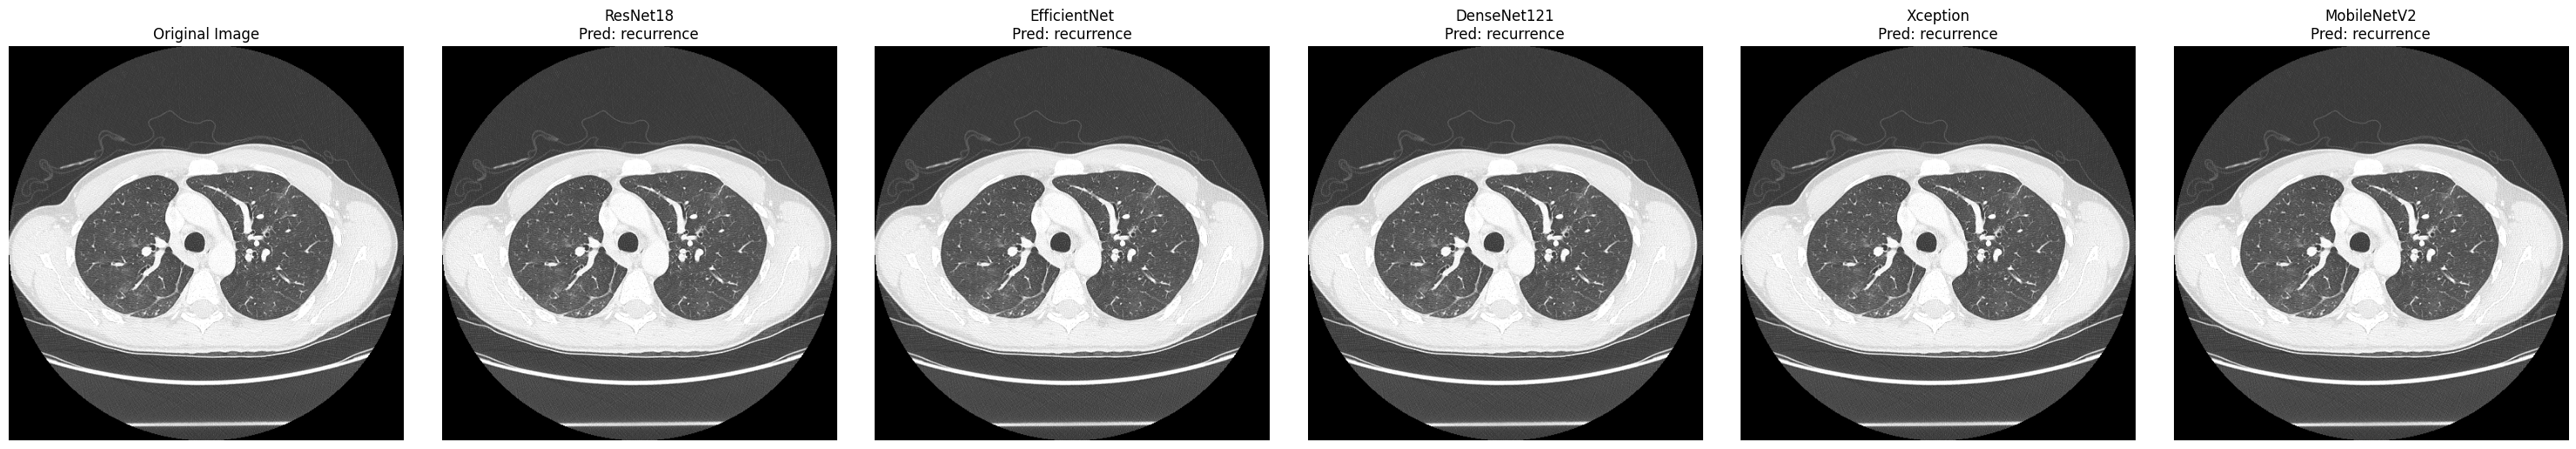


--- LIME Sample Prediction Summary ---
          Model  True Class Predicted Class  Confidence
0      ResNet18  recurrence      recurrence    1.000000
1  EfficientNet  recurrence      recurrence    0.999993
2   DenseNet121  recurrence      recurrence    0.999979
3      Xception  recurrence      recurrence    0.999271
4   MobileNetV2  recurrence      recurrence    1.000000


In [41]:
# --- LIME Functions ---
def get_transform_for_lime(input_size):
    """Get transform without ToTensor for LIME's numpy input."""
    return transforms.Compose([
        transforms.Resize(input_size),
        # No ToTensor here
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalize expects Tensor, adjust predict_fn
    ])

def predict_fn_for_lime(model_name, numpy_images):
    """Prediction function compatible with LIME, handles numpy array input."""
    model = trained_models[model_name] # Assumes trained_models is accessible
    model.eval()
    input_size = models_definition[model_name]['input_size']
    # Manual transform: numpy -> PIL -> Resize -> ToTensor -> Normalize
    pil_imgs = [Image.fromarray(img.astype(np.uint8)) for img in numpy_images]
    transform = models_definition[model_name]['transform'] # Get the full transform including ToTensor and Normalize
    tensors = torch.stack([transform(img) for img in pil_imgs]).to(device)

    with torch.no_grad():
        outputs = model(tensors)
    probs = torch.softmax(outputs, dim=1)
    return probs.cpu().numpy()

def generate_lime(model_name, numpy_image):
    """Generates LIME explanation."""
    explainer = lime_image.LimeImageExplainer()
    # Provide the predict function specific to the model
    bound_predict_fn = lambda x: predict_fn_for_lime(model_name, x)

    # Define segmenter - adjust parameters as needed
    segmenter = SegmentationAlgorithm('quickshift', kernel_size=4, max_dist=200, ratio=0.2)

    explanation = explainer.explain_instance(
        numpy_image,
        bound_predict_fn,
        top_labels=num_classes, # Explain top classes
        hide_color=0,
        num_samples=1000, # Number of samples for LIME perturbation
        segmentation_fn=segmenter,
        random_seed=42
    )
    return explanation

def visualize_lime_results(original_pil_image, lime_explanations_dict, class_names, save_dir):
    """Visualize LIME explanations."""
    num_models = len(lime_explanations_dict)
    fig, axes = plt.subplots(1, num_models + 1, figsize=(5 * (num_models + 1), 5))
    axes[0].imshow(original_pil_image); axes[0].set_title("Original Image"); axes[0].axis("off")

    i = 1
    for model_name, explanation in lime_explanations_dict.items():
        if explanation is None:
            axes[i].text(0.5, 0.5, "LIME Failed", ha='center', va='center', color='red'); axes[i].set_title(model_name)
        else:
            pred_class_idx = explanation.top_labels[0]
            pred_class_name = class_names[pred_class_idx]
            # Get image and mask for the top predicted class
            try:
                temp, mask = explanation.get_image_and_mask(
                    pred_class_idx, positive_only=True, num_features=10, hide_rest=False, min_weight=0.01
                )
                axes[i].imshow(temp); axes[i].set_title(f"{model_name}\nPred: {pred_class_name}")
            except Exception as viz_e:
                 print(f"Error visualizing LIME for {model_name}: {viz_e}")
                 axes[i].text(0.5, 0.5, "Viz Error", ha='center', va='center', color='red'); axes[i].set_title(model_name)

        axes[i].axis("off")
        i += 1
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "lime_explanations.png"))
    plt.show()

# --- Execute LIME ---
print("\n--- Generating LIME Explanations for a Sample Image ---")
# Select a random image from the test set
if test_subset:
    random_idx = random.randrange(len(test_subset))
    sample_pil_image, sample_label_idx = test_subset[random_idx] # Get PIL image and label
    sample_image_np = np.array(sample_pil_image) # Convert to numpy for LIME
    true_class_name = class_names[sample_label_idx]
    print(f"Explaining image {random_idx} (True Class: {true_class_name})")

    lime_explanations = {}
    lime_results_list = []

    for model_name, model in trained_models.items():
        print(f"  Generating LIME for {model_name}...")
        try:
            # Get model prediction first
            transform = models_definition[model_name]['transform']
            input_tensor = transform(sample_pil_image).unsqueeze(0).to(device)
            with torch.no_grad():
                 outputs = model(input_tensor)
                 probs = torch.softmax(outputs, dim=1)
                 conf, pred_idx = torch.max(probs, dim=1)
            pred_class_name = class_names[pred_idx.item()]

            # Generate explanation
            explanation = generate_lime(model_name, sample_image_np)
            lime_explanations[model_name] = explanation
            lime_results_list.append({
                "Model": model_name,
                "True Class": true_class_name,
                "Predicted Class": pred_class_name,
                "Confidence": conf.item()
            })
        except Exception as e:
            print(f"  LIME failed for {model_name}: {e}")
            lime_explanations[model_name] = None
            lime_results_list.append({
                "Model": model_name, "True Class": true_class_name, "Predicted Class": "Error", "Confidence": 0.0
            })


    # Visualize LIME results
    visualize_lime_results(sample_pil_image, lime_explanations, class_names, PLOTS_SAVE_DIR)

    # Display LIME prediction summary
    lime_results_df = pd.DataFrame(lime_results_list)
    print("\n--- LIME Sample Prediction Summary ---")
    print(lime_results_df)
    lime_results_df.to_csv(os.path.join(PLOTS_SAVE_DIR, "lime_sample_summary.csv"), index=False)

else:
    print("Test set is empty, skipping LIME explanation.")



--- Generating and Displaying LIME Explanations for a Sample Image ---
Explaining image index 216 (True Class: recurrence)


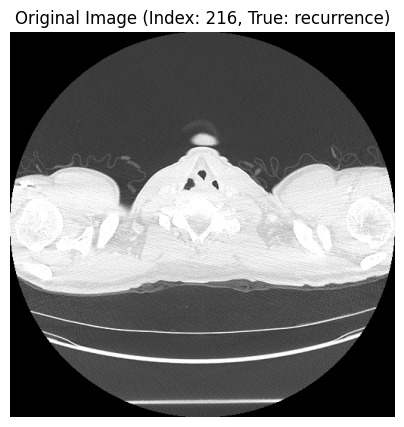


--- LIME for ResNet18 ---
  Model Prediction: recurrence (Confidence: 1.0000)
  Generating LIME explanation...


  0%|          | 0/1000 [00:00<?, ?it/s]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


  LIME explanation generated.


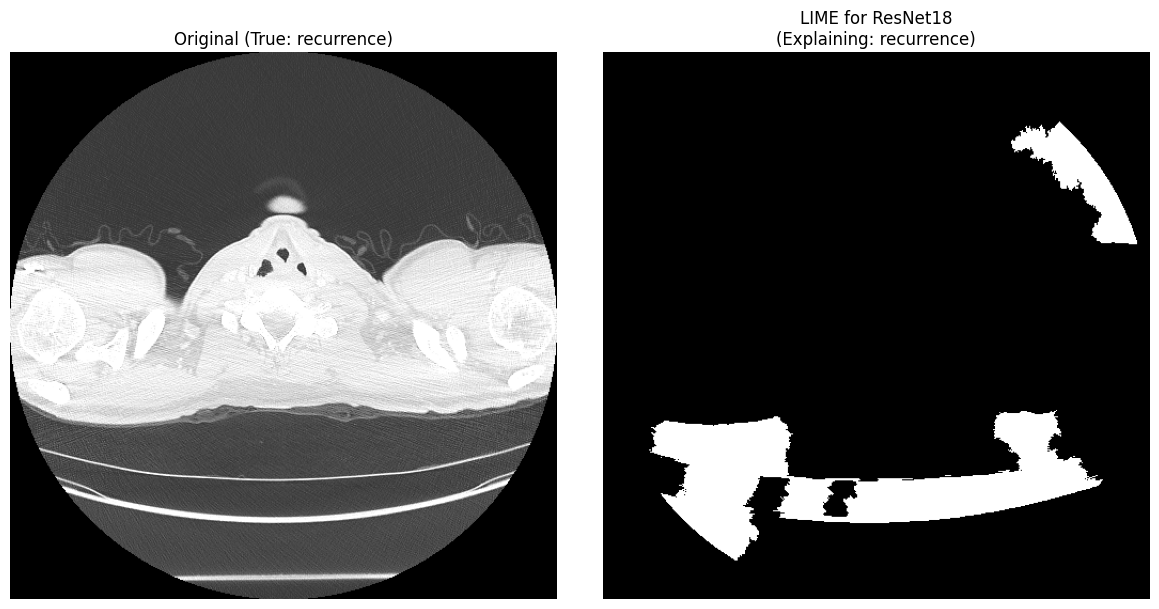

--------------------

--- LIME for EfficientNet ---
  Model Prediction: recurrence (Confidence: 1.0000)
  Generating LIME explanation...


  0%|          | 0/1000 [00:00<?, ?it/s]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


  LIME explanation generated.


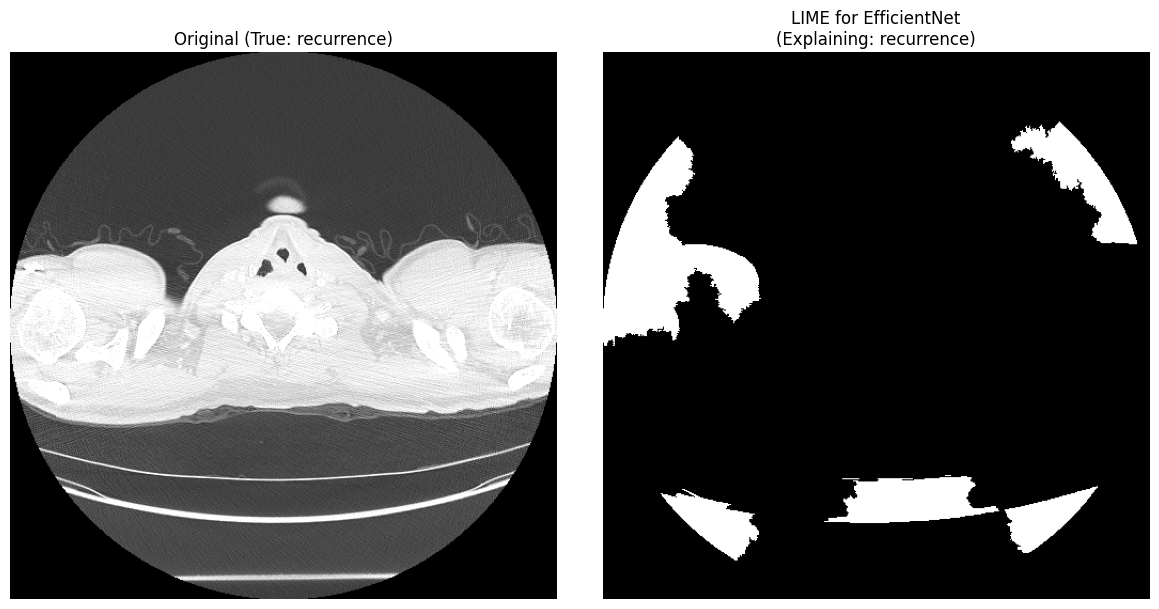

--------------------

--- LIME for DenseNet121 ---
  Model Prediction: recurrence (Confidence: 1.0000)
  Generating LIME explanation...


  0%|          | 0/1000 [00:00<?, ?it/s]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


  LIME explanation generated.


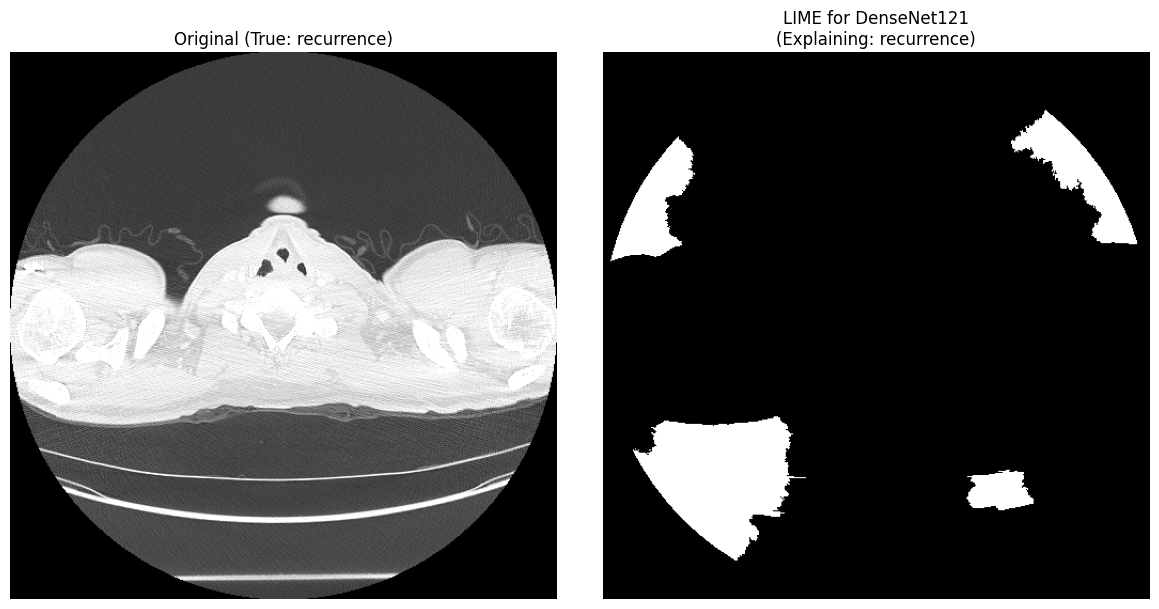

--------------------

--- LIME for Xception ---
  Model Prediction: recurrence (Confidence: 0.9994)
  Generating LIME explanation...


  0%|          | 0/1000 [00:00<?, ?it/s]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


  LIME explanation generated.


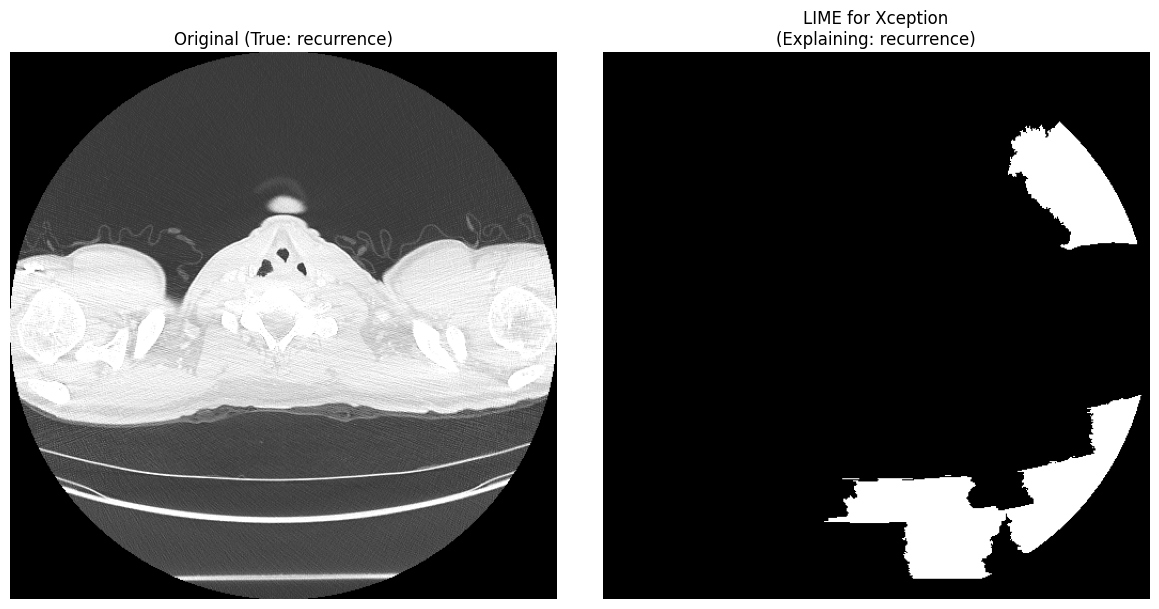

--------------------

--- LIME for MobileNetV2 ---
  Model Prediction: recurrence (Confidence: 1.0000)
  Generating LIME explanation...


  0%|          | 0/1000 [00:00<?, ?it/s]

  LIME explanation generated.


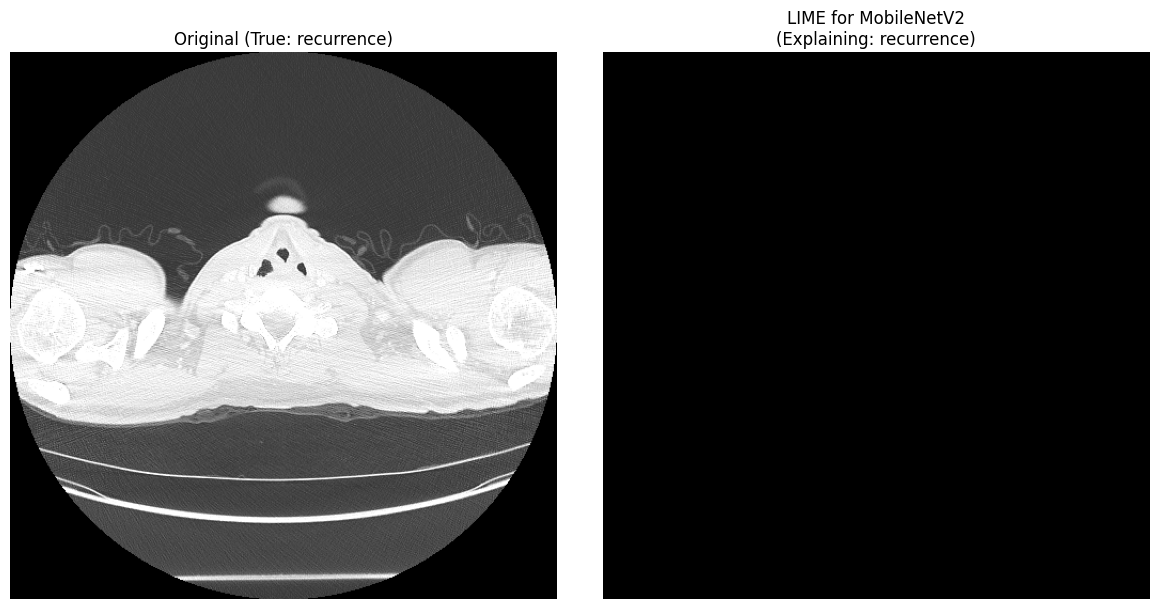

--------------------

--- LIME Sample Prediction Summary ---
          Model  True Class Predicted Class  Confidence
0      ResNet18  recurrence      recurrence    0.999989
1  EfficientNet  recurrence      recurrence    0.999995
2   DenseNet121  recurrence      recurrence    0.999952
3      Xception  recurrence      recurrence    0.999364
4   MobileNetV2  recurrence      recurrence    1.000000
LIME summary saved to ./plots\lime_sample_summary.csv


In [45]:
# --- LIME Functions (Keep generate_lime, predict_fn_for_lime as defined previously) ---
# --- REMOVE the visualize_lime_results function ---
# def visualize_lime_results(original_pil_image, lime_explanations_dict, class_names, save_dir):
#     ... (function definition removed) ...


# --- Execute LIME (Modified) ---
print("\n--- Generating and Displaying LIME Explanations for a Sample Image ---")

# Select a random image from the test set
if test_subset and len(test_subset) > 0: # Ensure test_subset exists and is not empty
    random_idx = random.randrange(len(test_subset))
    # Get PIL image and label using the dataset's __getitem__ via subset
    sample_pil_image, sample_label_idx = test_subset[random_idx]
    sample_image_np = np.array(sample_pil_image) # Convert to numpy for LIME input
    true_class_name = class_names[sample_label_idx]
    print(f"Explaining image index {random_idx} (True Class: {true_class_name})")

    # Display the original image once at the start
    plt.figure(figsize=(5, 5))
    plt.imshow(sample_pil_image)
    plt.title(f"Original Image (Index: {random_idx}, True: {true_class_name})")
    plt.axis('off')
    plt.show() # Show original image

    lime_results_list = [] # Keep track of prediction results

    for model_name, model in trained_models.items():
        if model is None: continue # Skip if model wasn't loaded

        print(f"\n--- LIME for {model_name} ---")
        explanation_obj = None # Reset explanation for each model
        pred_class_name = "Error"
        conf_score = 0.0

        try:
            # Get model prediction first (needed for context, though LIME calculates its own)
            transform = models_definition[model_name]['transform']
            input_tensor = transform(sample_pil_image).unsqueeze(0).to(device)
            with torch.no_grad():
                 outputs = model(input_tensor)
                 probs = torch.softmax(outputs, dim=1)
                 conf, pred_idx = torch.max(probs, dim=1)
            pred_class_name = class_names[pred_idx.item()]
            conf_score = conf.item()
            print(f"  Model Prediction: {pred_class_name} (Confidence: {conf_score:.4f})")

            # Generate explanation
            print(f"  Generating LIME explanation...")
            explanation_obj = generate_lime(model_name, sample_image_np)
            print(f"  LIME explanation generated.")

            # Prepare result dictionary regardless of visualization success
            lime_results_list.append({
                "Model": model_name,
                "True Class": true_class_name,
                "Predicted Class": pred_class_name,
                "Confidence": conf_score
            })

            # --- Visualize LIME result immediately ---
            # --- Visualize LIME result immediately (Modified) ---
            if explanation_obj is not None:
                try:
                    # Get explanation for the top predicted label by LIME itself
                    lime_pred_label_idx = explanation_obj.top_labels[0]
                    lime_pred_label_name = class_names[lime_pred_label_idx]

                    # *** CHANGE 1: Use hide_rest=True ***
                    # Get the image showing ONLY the positive contributions
                    temp, mask = explanation_obj.get_image_and_mask(
                        lime_pred_label_idx,
                        positive_only=True,
                        num_features=10, # Keep or adjust this
                        hide_rest=True, # <<<--- SET TO TRUE
                        min_weight=0.01 # Keep or adjust this
                    )

                    # Create a plot with 2 subplots: Original vs LIME Explanation
                    fig, axes = plt.subplots(1, 2, figsize=(12, 6)) # 1 row, 2 columns

                    # Plot Original Image for comparison
                    axes[0].imshow(sample_pil_image) # Use the original PIL image
                    axes[0].set_title(f"Original (True: {true_class_name})")
                    axes[0].axis('off')

                    # Plot LIME Explanation (showing only important regions)
                    axes[1].imshow(temp)
                    axes[1].set_title(f"LIME for {model_name}\n(Explaining: {lime_pred_label_name})")
                    axes[1].axis('off')

                    # Save combined plot
                    plt.tight_layout()
                    plt.savefig(os.path.join(PLOTS_SAVE_DIR, f"lime_{model_name}_sample_{random_idx}.png"))
                    plt.show() # Display the plot immediately

                    # *** CHANGE 2: Optionally visualize the raw mask ***
                    # plt.figure(figsize=(6,6))
                    # plt.imshow(mask, cmap='gray')
                    # plt.title(f"LIME Mask for {model_name}")
                    # plt.axis('off')
                    # plt.show()
                    # ***************************************************

                except IndexError:
                     print("  Error: LIME explanation top_labels might be empty.")
                except Exception as viz_e:
                    print(f"  Error visualizing LIME explanation for {model_name}: {viz_e}")
            else:
                 print("  Skipping visualization as LIME explanation is None.")
            # ----------------------------------------

        except Exception as e:
            print(f"  LIME generation failed for {model_name}: {type(e).__name__} - {e}")
            # Append error result if explanation generation itself failed
            if not any(d['Model'] == model_name for d in lime_results_list): # Avoid duplicate errors if prediction worked but LIME failed
                lime_results_list.append({
                    "Model": model_name, "True Class": true_class_name, "Predicted Class": "LIME Error", "Confidence": 0.0
                })
        print("-" * 20) # Separator


    # Display LIME prediction summary table at the end
    if lime_results_list:
        lime_results_df = pd.DataFrame(lime_results_list)
        print("\n--- LIME Sample Prediction Summary ---")
        print(lime_results_df)
        try:
            lime_results_df.to_csv(os.path.join(PLOTS_SAVE_DIR, "lime_sample_summary.csv"), index=False)
            print(f"LIME summary saved to {os.path.join(PLOTS_SAVE_DIR, 'lime_sample_summary.csv')}")
        except Exception as e:
            print(f"Error saving LIME summary: {e}")

else:
    print("Test set is empty or not loaded, skipping LIME explanation.")

In [37]:
# --- Helper functions for plotting ---
def plot_training_history(history, model_name, save_dir):
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], marker='o', linestyle='-', label='Train Loss')
    plt.plot(epochs, history['val_loss'], marker='o', linestyle='-', label='Validation Loss')
    plt.title(f'{model_name} - Loss') ; plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], marker='o', linestyle='-', label='Train Accuracy')
    plt.plot(epochs, history['val_acc'], marker='o', linestyle='-', label='Validation Accuracy')
    plt.title(f'{model_name} - Accuracy'); plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f"{model_name}_training_history.png"))
    plt.close() # Close plot to avoid displaying inline if not desired

def plot_confusion_matrix(cm, classes, model_name, save_dir):
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(f'{model_name} - Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('True')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f"{model_name}_confusion_matrix.png"))
    plt.close()

def plot_roc_curve(fpr, tpr, roc_auc, model_name, save_dir):
    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title(f'{model_name} - ROC Curve')
    plt.legend(loc="lower right"); plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f"{model_name}_roc_curve.png"))
    plt.close()
def plot_tsne(embeddings, labels, classes, model_name, save_dir):
    """ Generates and saves a t-SNE plot. """
    print(f"  Generating t-SNE for {model_name}...")
    if not embeddings:
        print(f"  Skipping t-SNE for {model_name}: No embeddings collected.")
        return

    # Ensure embeddings is a numpy array
    embeddings_np = np.array(embeddings)
    # Ensure labels is a numpy array
    labels_np = np.array(labels)

    # Check if enough samples exist for t-SNE
    if embeddings_np.shape[0] < 2 : # Need at least 2 samples
        print(f"  Skipping t-SNE for {model_name}: Not enough samples ({embeddings_np.shape[0]})")
        return
    # Check if perplexity is valid (common issue)
    perplexity_value = min(30.0, max(5.0, embeddings_np.shape[0] - 1.0)) # Adjust perplexity based on sample size

    try:
        tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity_value, n_iter=300, init='pca') # Add init='pca', n_iter
        tsne_results = tsne.fit_transform(embeddings_np)

        # Create a DataFrame for easier plotting with seaborn
        tsne_df = pd.DataFrame({
            'tsne-1': tsne_results[:, 0],
            'tsne-2': tsne_results[:, 1],
            'label': [classes[l] for l in labels_np] # Map numerical labels to class names
        })

        plt.figure(figsize=(8, 6))
        sns.scatterplot(
            x="tsne-1", y="tsne-2",
            hue="label",
            palette=sns.color_palette("hsv", len(classes)), # Use distinct colors
            data=tsne_df,
            legend="full",
            alpha=0.7
        )
        plt.title(f'{model_name} - t-SNE Visualization')
        plt.xlabel("t-SNE Dimension 1")
        plt.ylabel("t-SNE Dimension 2")
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, f"{model_name}_tsne_plot.png"))
        plt.close()
        print(f"  t-SNE plot saved for {model_name}.")

    except Exception as e:
        print(f"  Error generating t-SNE for {model_name}: {e}")